<a href="https://colab.research.google.com/github/Abrar-404/AI-ML_Practices_and_Assignments/blob/main/Eid_Vacation_Practice_Advanced.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing, load_diabetes, load_breast_cancer, load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from ucimlrepo import fetch_ucirepo
from sklearn.impute import SimpleImputer

In [3]:
pip install ucimlrepo

# Q1  The Income Trap

# DATASET Adult Income (Census Income)  
https://archive.ics.uci.edu/dataset/2/adult

### RESEARCH
### Read about what 'capital-gain' and 'capital-loss' represent in US income

## Theory
1. The 'capital-gain' column has ~91% of its values equal to exactly zero, with a
few extreme values reaching over $99,000. Is this an outlier problem or a
distributional problem? Justify your answer using the concept of the Normal
Distribution from class.
2. If you apply StandardScaler (Z-score normalization) to 'capital-gain', what
happens to the Z-scores of those extreme values? Why would a RobustScaler be
more appropriate here?  
3. Explain Winsorization. If you apply 5th–95th percentile Winsorization to
'hours-per-week', what are you assuming about the data-generating process, and
what are the risks?


##  Practical
4. Load the dataset (it uses '?' for missing values — handle this first). Perform
train-test split. Plot the distribution of 'capital-gain' using a KDE plot. Confirm
the extreme skew visually.
5. Apply Winsorization (clip at 5th–95th percentile) to 'capital-gain' on the training
set. Apply the SAME clipping bounds to the test set. Plot before/after KDE
plots.
6. Apply RobustScaler to 'hours-per-week' and 'capital-gain' . Compare the scaled
range with what StandardScaler would have produced. Which handles the
outliers better? Justify numerically.

#### THEORY

1. It's a distributional problem. A Normal Distribution assumes values spread symmetrically around a mean. Here, 91% are exactly 0 and a few go to $99000. This is a zero-inflated distribution, not a Normal one with outliers. The extreme values aren't errors they're real wealthy people's capital gains. It can't be fixed  with outlier removal.

2. StandardScaler computes Z = (x - mean) / std. Since 91% of values are 0 and a few are huge, the mean gets pulled up and the std gets inflated by those extremes. The Z-scores of the extreme values won't look as extreme as they should, and the Z-scores of the zeros will become oddly negative. RobustScaler uses median and IQR instead since the median of capital-gain is 0 (most people have 0), it's not affected by the extreme values at all.

3. Instead of removing outliers, it should be capped. If I apply 5th–95th percentile Winsorization to hours-per-week:
- Any value below the 5th percentile gets replaced with the 5th percentile value
- Any value above the 95th percentile gets replaced with the 95th percentile value.

Assumption I'm making:
Values beyond those percentiles are measurement errors or noise, not real data points.

Risks:

If those extreme values are real (someone genuinely works 90 hrs/week), it's distorting the truth
It must be computed the bounds on the training set only, then apply the same bounds to the test set otherwise it's leaking test data information

/tmp/ipykernel_32971/466455033.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.replace('?', np.nan, inplace = True)


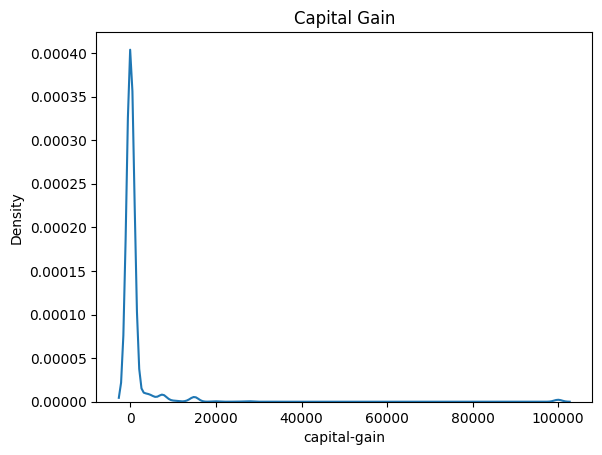

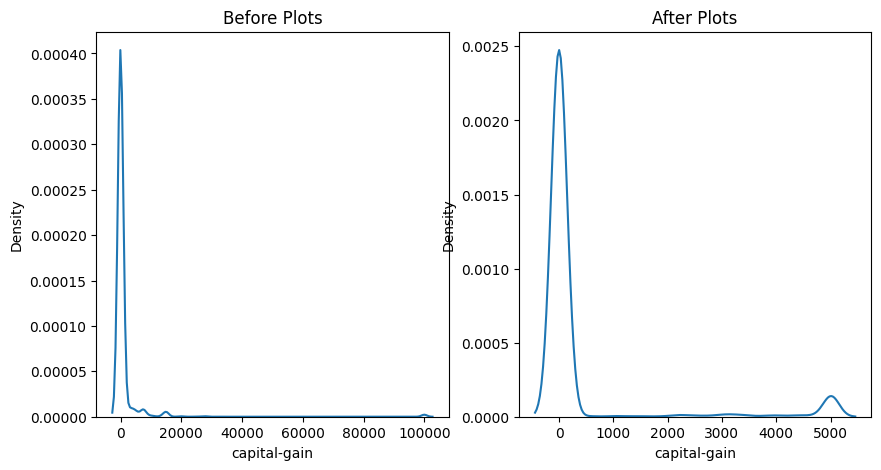

Robust Scaler: 
      hours-per-week  capital-gain
min            -7.8           0.0
max            11.8        5013.0
Standard Scaler: 
      hours-per-week  capital-gain
min       -3.179147     -0.290364
max        4.728217      3.807335


In [4]:
# load dataset
adult = fetch_ucirepo(id=2)
X = adult.data.features
y = adult.data.targets

# handle missing value
X.replace('?', np.nan, inplace = True)

df_adult = pd.concat([X, y], axis = 1)

X = df_adult.drop('income', axis = 1)
y = df_adult['income']
# Perform train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#  Plot the distribution of 'capital-gain' using a KDE plot. Confirm the extreme skew visually.
sns.kdeplot(data = X_train, x = 'capital-gain')
plt.title('Capital Gain')
plt.show()

# Apply Winsorization (clip at 5th–95th percentile) to 'capital-gain' on the training set
X_train_original = X_train['capital-gain'].copy()
x = 5
x = x/100
min_range = X_train['capital-gain'].quantile(x)
max_range = X_train['capital-gain'].quantile(1 - x)

# Apply the SAME clipping bounds to the test set.
X_train['capital-gain'] = X_train['capital-gain'].clip(min_range, max_range)
X_test['capital-gain'] = X_test['capital-gain'].clip(min_range, max_range)

# Plot before/after KDE plots.
fig, axes = plt.subplots(1, 2, figsize = (10, 5))
sns.kdeplot(x = X_train_original, ax = axes[0]).set_title('Before Plots')
sns.kdeplot(data = X_train, x = 'capital-gain', ax = axes[1]).set_title('After Plots')
plt.show()

# Apply RobustScaler to 'hours-per-week' and 'capital-gain'
cols = ['hours-per-week', 'capital-gain']
rs = RobustScaler()
X_train_rs = pd.DataFrame(rs.fit_transform(X_train[cols]), columns = cols)
X_test_rs = pd.DataFrame(rs.transform(X_test[cols]), columns = cols)

ss = StandardScaler()
X_train_ss = pd.DataFrame(ss.fit_transform(X_train[cols]), columns = cols)
X_test_ss = pd.DataFrame(ss.transform(X_test[cols]), columns = cols)

print('Robust Scaler: \n', X_train_rs[cols].describe().loc[['min', 'max']])
print('Standard Scaler: \n', X_train_ss[cols].describe().loc[['min', 'max']])

# Q2  The Churning Machine

# DATASET
Telco Customer Churn   
https://www.kaggle.com/datasets/blastchar/telco-customer-churn

# RESEARCH
Research what 'churn' means in the telecom industry and why it is a
critical business KPI before starting.

# Theory
7. The target column 'Churn' has roughly 73% 'No' and 27% 'Yes'. Explain why
this class imbalance matters for a model. If you don't address it, what kind of
predictions might the model make?
8. The 'TotalCharges' column is stored as a string (object) despite being numeric.
What is the likely reason? (Hint: look at what happens with customers who have
0 tenure.) What preprocessing step is needed?
9. From an EDA perspective, what is the difference between a countplot with hue

# Practical
10. Load the dataset. Fix the 'TotalCharges' data type issue. Confirm by
checking df.info() before and after.
11. Perform full univariate analysis: (a) For all categorical columns, create
countplots; (b) For all numerical columns, plot histograms with kde=True. Write
at least one business insight per plot.
12. Perform multivariate analysis: (a) Create a countplot of 'Contract' vs 'Churn'
with hue; (b) Create a KDE plot of 'tenure' grouped by 'Churn';Describe two
findings that would help a business reduce churn.

# Theory
1. The imbalance matters for a model because when the model trains it becomes bias because of 73% No and only 27% Yes. If I don't address it the model will predict based on the higher percentage of value instead of scaling the data which should be meaningful.
2. TotalCharges stored as string:
Customers with 0 tenure (brand new, never billed) have a empty string in TotalCharges instead of 0. Pandas reads the whole column as object (string) because of these whitespace entries. The fix: replace " " with NaN, then pd.to_numeric(..., errors='coerce'), then fill or drop those NaN rows.
3. Standard Countplot Shows the total number of observations (frequency) for each category. On the other hand, countplot with hue Shows the distribution of a primary categorical variable but breaks down each bar into a secondary categorical variable using different colors

# Practical

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


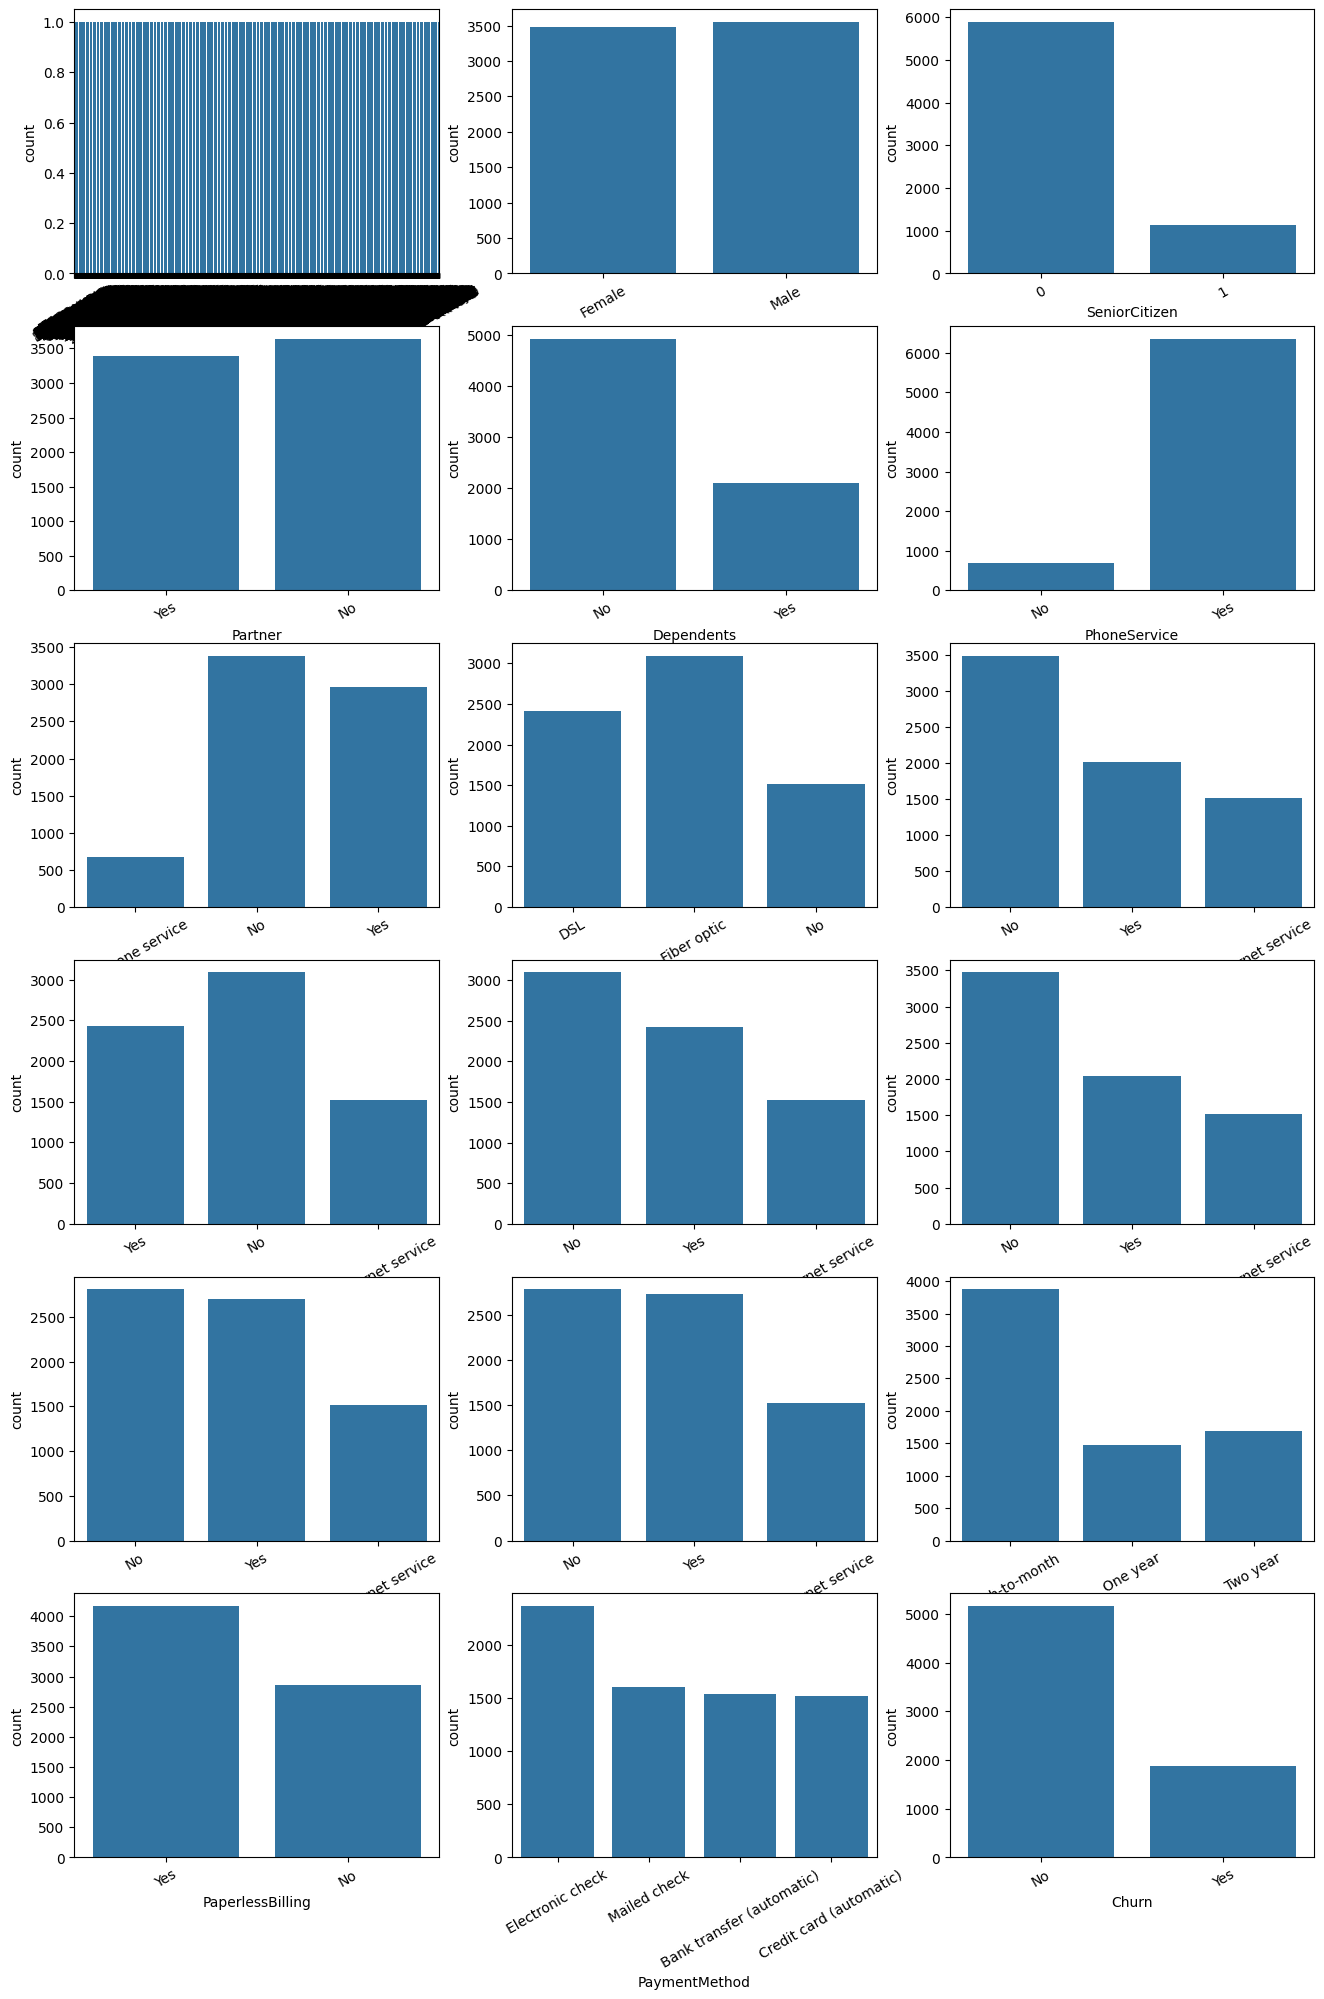

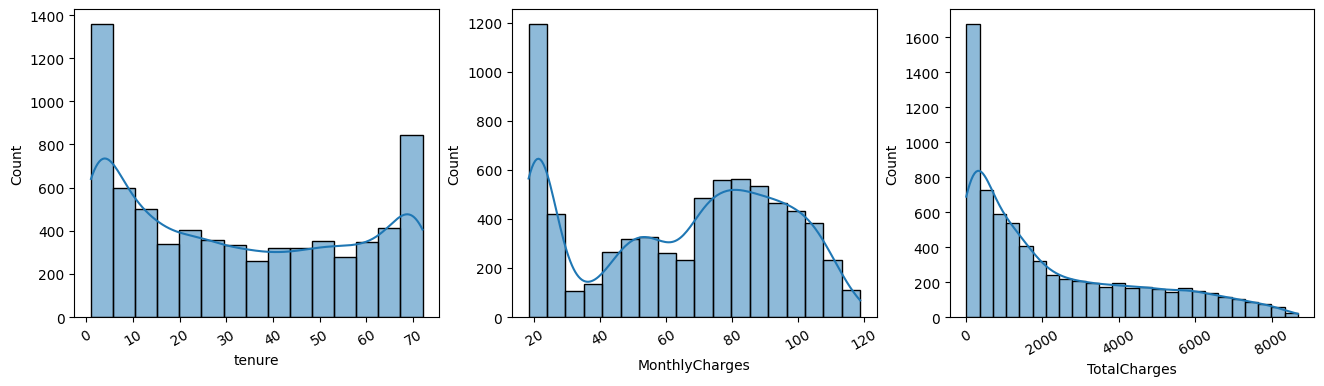

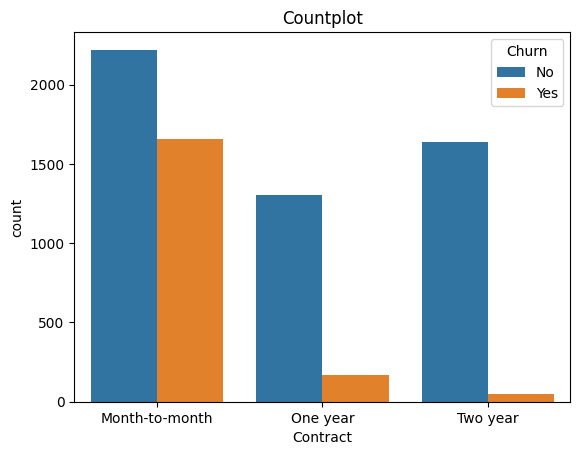

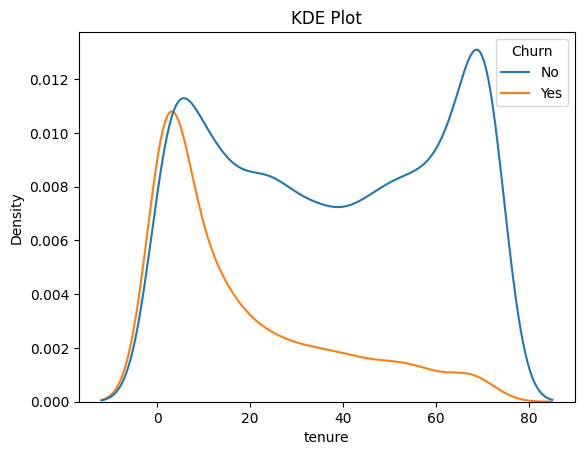

In [16]:
# load dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
# Before
print(df.info())

df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')
df.dropna(subset = ['TotalCharges'], inplace = True)

# After
print(df.info())

# Perform full univariate analysis:
# (a) For all categorical columns, create countplots
df_cat = df.drop(["tenure", "MonthlyCharges", "TotalCharges"], axis = 1)
df_num = df[["tenure", "MonthlyCharges", "TotalCharges"]]

fig, axes = plt.subplots(6, 3, figsize = (16, 24))
axes = axes.ravel()

for i, col in enumerate(df_cat):
  sns.countplot(data = df, x = col, ax = axes[i])
  axes[i].tick_params(axis='x', rotation=30)
plt.show()

# (b) For all numerical columns, plot histograms with kde=True.
fig, axes = plt.subplots(1, 3, figsize = (16, 4))
axes = axes.ravel()
for i, cols in enumerate(df_num):
  sns.histplot(data = df, x = cols, kde = True, ax = axes[i])
  axes[i].tick_params(axis='x', rotation=30)
plt.show()

# Perform multivariate analysis:
# (a) Create a countplot of 'Contract' vs 'Churn' with hue
sns.countplot(data = df, x = 'Contract', hue = 'Churn').set_title('Countplot')
plt.show()
# Finding 1: Customers on month-to-month contracts leave the most. Almost half of them churn (~43%). But customers who signed a 1 or 2 year contract barely leave (~3%).
# Business action: offer a discount or free add-on to move customers onto annual plans

# Create a KDE plot of 'tenure' grouped by 'Churn'
sns.kdeplot(data = df, x = 'tenure', hue = 'Churn').set_title('KDE Plot')
plt.show()
# Finding 2: Tenure means how many months a customer has been with the company. Customers who leave mostly do so within the first 12 months. Customers who stay longer than 2 years almost never leave.
# Business action: Focus retention efforts on new customers. Send them welcome offers, check-in calls, and loyalty rewards at month 1, 3, and 6. If you can keep them happy through the first year, they will most likely stay forever.

# Q3  Z-Scores & The Empirical Rule in the Wild   

# DATASET
Medical Cost Personal Dataset  
https://www.kaggle.com/datasets/mirichoi0218/insurance

# RESEARCH
Research what BMI (Body Mass Index) is, what the clinical thresholds are
(underweight, normal, overweight, obese), and why it might be a critical
feature for insurance charges.

#  Theory
13. According to the Empirical Rule (68-95-99.7), if BMI is approximately
normally distributed with mean=30 and std=6, what percentage of people have
BMI above 42?  
14. You detect that the 'charges' column has a Z-score outlier threshold at |Z| >
3. A student removes ALL rows with |Z| > 3 before the train-test split. Identify
two problems with this approach.
15. Why might the IQR method detect different outliers than the Z-score
method on the same column? In which situation is each method preferred?

# Practical
16. Load the dataset. Verify whether 'bmi' follows an approximately normal
distribution: (a) Plot a KDE plot; (b) Compute skewness   
17. For the 'charges' column: (a) Identify outliers using the IQR method  (b)
Identify outliers using the Z-score method (c) Compare how many outliers each
method detects. Which is more conservative?
18. Create a new feature 'bmi_category' using the WHO thresholds
(Underweight < 18.5, Normal 18.5–24.9, Overweight 25–29.9, Obese >= 30).
Then use a barplot to visualize average 'charges' per BMI category. What pattern
do you see?